In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.ensemble import (BaggingClassifier, AdaBoostClassifier,
                               GradientBoostingClassifier, RandomForestClassifier,
                               StackingClassifier)

from sklearn.metrics import (accuracy_score, mean_squared_error,
                             confusion_matrix, classification_report,
                             roc_curve, auc)

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset shape  :", X.shape)
print("Class distribution:\n",
      y.value_counts().rename({0: "Malignant", 1: "Benign"}))
X.head()

Dataset shape  : (569, 30)
Class distribution:
 Benign       357
Malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test     samples : {X_test.shape[0]}")

Training samples : 455
Test     samples : 114


In [5]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    max_samples=0.8,
    max_features=0.8,       
    bootstrap=True,         
    random_state=42
)
bagging_model.fit(X_train, y_train)
y_pred_bag = bagging_model.predict(X_test)

print("── Bagging Results ──────────────────────")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_bag):.4f}")
print(f"  MSE      : {mean_squared_error(y_test, y_pred_bag):.4f}")

cv_bag = cross_val_score(bagging_model, X, y, cv=5, scoring='accuracy')
print(f"  CV Score : {cv_bag.mean():.4f} ± {cv_bag.std():.4f}")

── Bagging Results ──────────────────────
  Accuracy : 0.9561
  MSE      : 0.0439
  CV Score : 0.9526 ± 0.0312


In [6]:
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)

print("── AdaBoost Results ─────────────────────")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_ada):.4f}")
print(f"  MSE      : {mean_squared_error(y_test, y_pred_ada):.4f}")

── AdaBoost Results ─────────────────────
  Accuracy : 0.9561
  MSE      : 0.0439


In [7]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("\n── Gradient Boosting Results ────────────")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"  MSE      : {mean_squared_error(y_test, y_pred_gb):.4f}")

cv_gb = cross_val_score(gb_model, X, y, cv=5, scoring='accuracy')
print(f"  CV Score : {cv_gb.mean():.4f} ± {cv_gb.std():.4f}")


── Gradient Boosting Results ────────────
  Accuracy : 0.9474
  MSE      : 0.0526
  CV Score : 0.9631 ± 0.0203


In [8]:
base_learners = [
    ('dt',  DecisionTreeClassifier(max_depth=4, random_state=42)),
    ('rf',  RandomForestClassifier(n_estimators=50, random_state=42)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
]

meta_learner = LogisticRegression(max_iter=1000)

stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    passthrough=False        
)
stacking_model.fit(X_train_sc, y_train)
y_pred_stack = stacking_model.predict(X_test_sc)

print("── Stacking Results ─────────────────────")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_stack):.4f}")
print(f"  MSE      : {mean_squared_error(y_test, y_pred_stack):.4f}")

cv_stack = cross_val_score(stacking_model, X_test_sc, y_test, cv=3)
print(f"  CV Score : {cv_stack.mean():.4f} ± {cv_stack.std():.4f}")

── Stacking Results ─────────────────────
  Accuracy : 0.9825
  MSE      : 0.0175
  CV Score : 0.9474 ± 0.0215


In [9]:
rf_model = RandomForestClassifier(
    n_estimators=100,        # number of trees
    max_depth=None,          # grow full trees
    max_features='sqrt',     # √(n_features) features per split
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    oob_score=True,          # out-of-bag score estimate
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("── Random Forest Results ────────────────")
print(f"  Accuracy       : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  MSE            : {mean_squared_error(y_test, y_pred_rf):.4f}")
print(f"  OOB Score      : {rf_model.oob_score_:.4f}")

cv_rf = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
print(f"  CV Score       : {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")

── Random Forest Results ────────────────
  Accuracy       : 0.9561
  MSE            : 0.0439
  OOB Score      : 0.9538
  CV Score       : 0.9561 ± 0.0228


In [11]:
models_info = {
    "Bagging"           : y_pred_bag,
    "AdaBoost"          : y_pred_ada,
    "Gradient Boosting" : y_pred_gb,
    "Stacking"          : y_pred_stack,
    "Random Forest"     : y_pred_rf,
}

rows = []
for name, y_pred in models_info.items():
    rows.append({
        "Model"        : name,
        "Accuracy (%)" : round(accuracy_score(y_test, y_pred) * 100, 2),
        "MSE"          : round(mean_squared_error(y_test, y_pred), 4),
        "Error (%)"    : round((1 - accuracy_score(y_test, y_pred)) * 100, 2),
    })

df_results = pd.DataFrame(rows).set_index("Model")
print(df_results.to_string())

                   Accuracy (%)     MSE  Error (%)
Model                                             
Bagging                   95.61  0.0439       4.39
AdaBoost                  95.61  0.0439       4.39
Gradient Boosting         94.74  0.0526       5.26
Stacking                  98.25  0.0175       1.75
Random Forest             95.61  0.0439       4.39


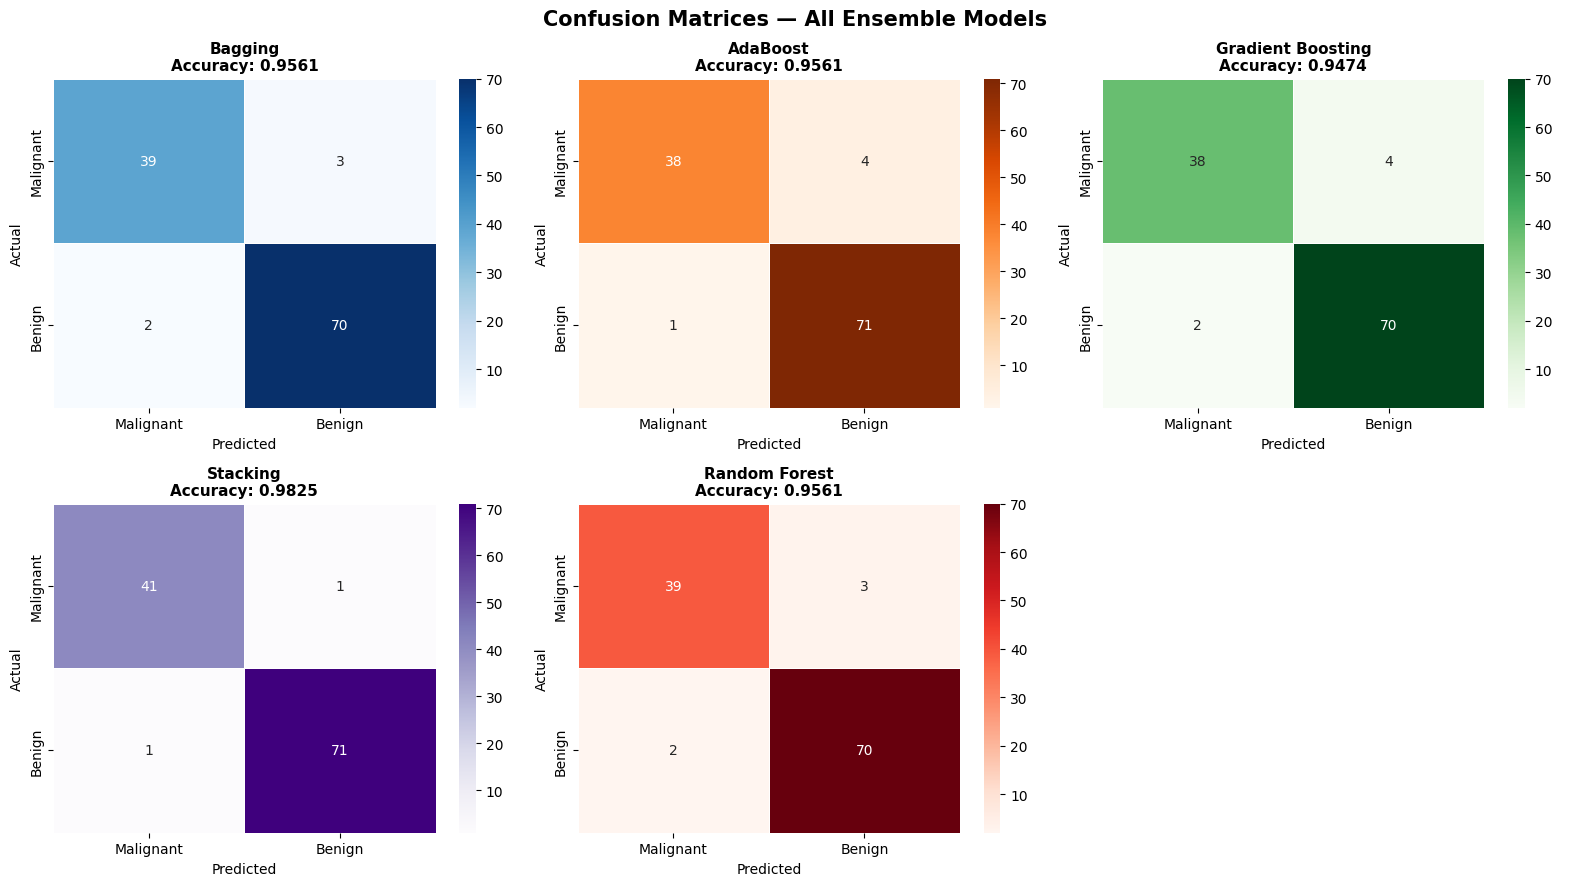

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
labels = ["Malignant", "Benign"]
colors = ['Blues', 'Oranges', 'Greens', 'Purples', 'Reds']

for ax, (name, y_pred), cmap in zip(axes, models_info.items(), colors):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=labels, yticklabels=labels,
                ax=ax, linewidths=0.5)
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f"{name}\nAccuracy: {acc:.4f}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

axes[-1].axis('off')   # hide empty 6th subplot
plt.suptitle("Confusion Matrices — All Ensemble Models", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

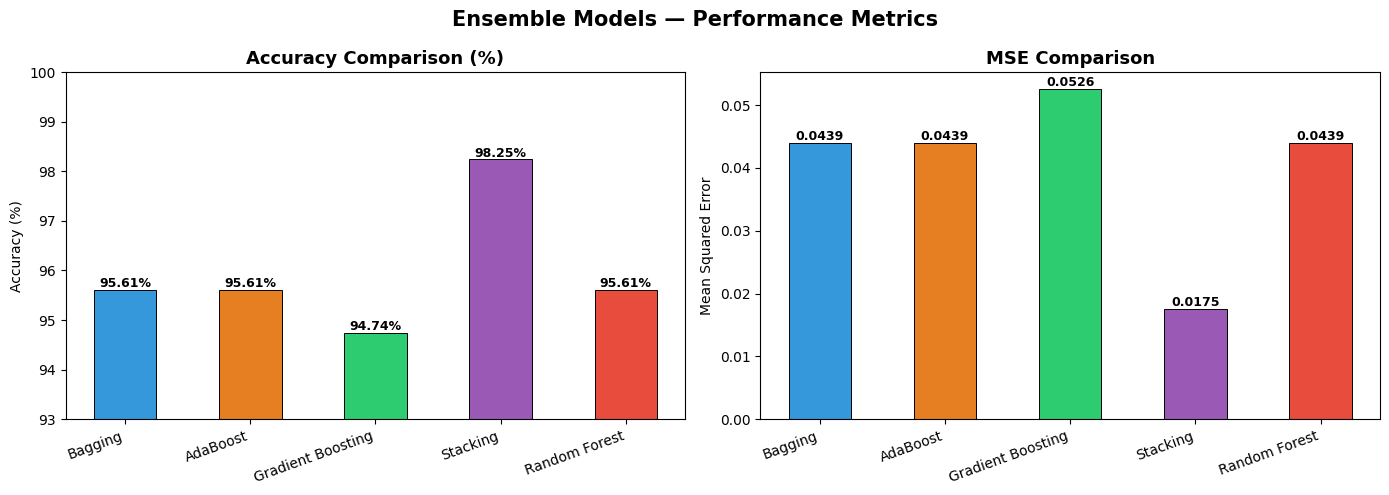

In [13]:
# ── Cell 12: Bar Chart Comparison ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = ["#3498db", "#e67e22", "#2ecc71", "#9b59b6", "#e74c3c"]
x = np.arange(len(df_results))
width = 0.5

# Accuracy
bars1 = axes[0].bar(x, df_results["Accuracy (%)"], color=palette,
                    width=width, edgecolor='black', linewidth=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_results.index, rotation=20, ha='right')
axes[0].set_ylim(93, 100)
axes[0].set_title("Accuracy Comparison (%)", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Accuracy (%)")
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f"{bar.get_height():.2f}%", ha='center', fontsize=9, fontweight='bold')

# MSE
bars2 = axes[1].bar(x, df_results["MSE"], color=palette,
                    width=width, edgecolor='black', linewidth=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_results.index, rotation=20, ha='right')
axes[1].set_title("MSE Comparison", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Mean Squared Error")
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0005,
                 f"{bar.get_height():.4f}", ha='center', fontsize=9, fontweight='bold')

plt.suptitle("Ensemble Models — Performance Metrics", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

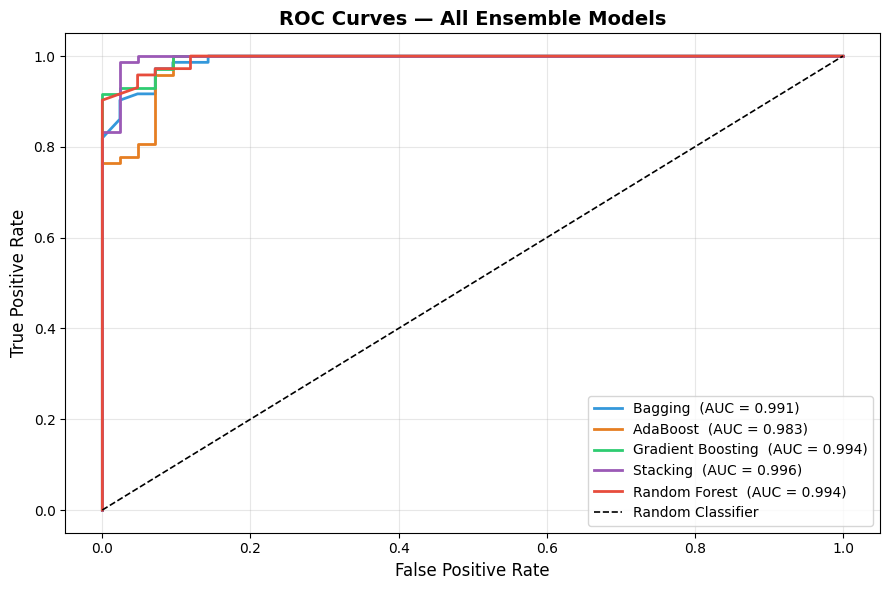

In [14]:
roc_models = {
    "Bagging"           : (bagging_model,  X_test,    "predict_proba"),
    "AdaBoost"          : (ada_model,      X_test,    "predict_proba"),
    "Gradient Boosting" : (gb_model,       X_test,    "predict_proba"),
    "Stacking"          : (stacking_model, X_test_sc, "predict_proba"),
    "Random Forest"     : (rf_model,       X_test,    "predict_proba"),
}

plt.figure(figsize=(9, 6))
for (name, (model, X_t, _)), color in zip(roc_models.items(), palette):
    proba   = model.predict_proba(X_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name}  (AUC = {roc_auc:.3f})", color=color, lw=2)

plt.plot([0,1], [0,1], 'k--', lw=1.2, label='Random Classifier')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves — All Ensemble Models", fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

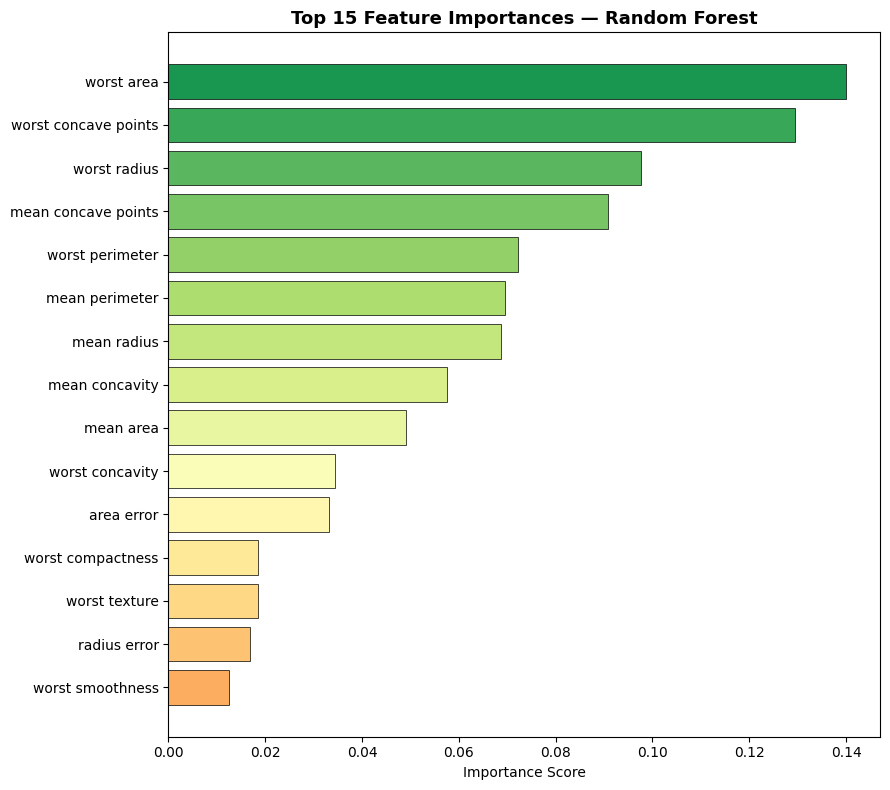

In [16]:
importances = pd.Series(rf_model.feature_importances_,
                        index=data.feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
bars = ax.barh(importances.index[-15:], importances.values[-15:],
               color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, 15)),
               edgecolor='black', linewidth=0.5)
ax.set_title("Top 15 Feature Importances — Random Forest",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [17]:
for name, y_pred in models_info.items():
    print(f"\n{'='*52}")
    print(f"  {name} — Classification Report")
    print('='*52)
    print(classification_report(y_test, y_pred,
                                target_names=["Malignant", "Benign"]))


  Bagging — Classification Report
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


  AdaBoost — Classification Report
              precision    recall  f1-score   support

   Malignant       0.97      0.90      0.94        42
      Benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


  Gradient Boosting — Classification Report
              precision    recall  f1-score   support

   Malignant       0.95      0.90      0.93        42
      Benign       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg